# Modélisation : Classification du Churn

**Objectif :** entraîner, comparer et sélectionner le meilleur modèle de prédiction du churn.

**4 modèles comparés :**
| Modèle | Rôle | Déséquilibre |
|---|---|---|
| Logistic Regression | Baseline interprétable | `class_weight='balanced'` |
| Random Forest | Non-linéaire, robuste | `class_weight='balanced'` |
| XGBoost | Gradient boosting, performant | `scale_pos_weight` |
| MLP (Keras) | Deep learning tabulaire | `class_weight` dict |

**Métriques retenues :** F1-score (churn=1), Recall, Precision, ROC-AUC, PR-AUC

**Pourquoi ces métriques et pas l'accuracy ?**
Avec 10.2% de churners, un modèle qui prédit toujours 0 atteint 89.8% d'accuracy.
C'est le paradoxe de la précision sur données déséquilibrées. On préfère :
- **F1** : compromis recall/precision sur la classe minoritaire
- **PR-AUC** : aire sous la courbe Precision-Recall, insensible au déséquilibre
- **Recall** : priorité à la détection des churners (un FN = un client perdu)

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, confusion_matrix,
    classification_report,
)
from scipy.stats import randint, uniform, loguniform

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

ROOT       = Path('..').resolve()
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Charger les artefacts du notebook 02
arts = joblib.load(MODELS_DIR / 'preprocessing_artifacts.joblib')
X_train_proc   = arts['X_train_proc']
X_val_proc     = arts['X_val_proc']
X_test_proc    = arts['X_test_proc']
y_train        = arts['y_train']
y_val          = arts['y_val']
y_test         = arts['y_test']
X_test_raw     = arts['X_test_raw']
FEATURE_NAMES  = arts['feature_names']

# ratio pour scale_pos_weight (XGBoost)
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train : {X_train_proc.shape} | Val : {X_val_proc.shape} | Test : {X_test_proc.shape}')
print(f'scale_pos_weight : {scale_pw:.2f}  (ratio majoritaire/minoritaire)')

Train : (7000, 50) | Val : (1500, 50) | Test : (1500, 50)
scale_pos_weight : 8.79  (ratio majoritaire/minoritaire)


## 1. Diagnostic : pourquoi le F1 était de 0.3 ?

Avant de construire les bons modèles, comprendre pourquoi l'ancienne version produisait F1≈0.3.
Deux causes cumulées :
1. **Déséquilibre non traité** : sans `class_weight`, le modèle apprend à prédire presque toujours 0
2. **Seuil 0.5 inadapté** : sur une distribution calibrée à 10% de positifs, même un bon modèle
   produit des probabilités inférieures à 0.5 pour la majorité des churners

In [5]:
# Reproduction du problème initial
lr_naive = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_naive.fit(X_train_proc, y_train)
proba_naive = lr_naive.predict_proba(X_val_proc)[:, 1]
pred_naive_05 = (proba_naive >= 0.5).astype(int)

print(f'Predictions churn=1 : {pred_naive_05.sum()} / {len(pred_naive_05)} clients')
print(f'F1-score   : {f1_score(y_val, pred_naive_05):.4f} ')
print(f'Recall     : {recall_score(y_val, pred_naive_05):.4f}')
print(f'Precision  : {precision_score(y_val, pred_naive_05, zero_division=0):.4f}')


Predictions churn=1 : 16 / 1500 clients
F1-score   : 0.0828 
Recall     : 0.0458
Precision  : 0.4375


## 2. Fonction utilitaire : calcul des métriques

In [7]:
def get_metrics(y_true, y_pred, y_proba, model_name=''):
    """Calcule toutes les métriques de classification pour la classe churn=1."""
    return {
        'model':     model_name,
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_true, y_proba), 4),
        'pr_auc':    round(average_precision_score(y_true, y_proba), 4),
    }


def find_optimal_threshold(y_true, y_proba, beta=1.0):
    """Trouve le seuil qui maximise le F-beta score sur la courbe PR."""
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # F-beta : beta>1 privilégie le recall (coût FN > FP)
    f_scores = (1 + beta**2) * precisions * recalls / (
        (beta**2 * precisions) + recalls + 1e-8
    )
    best_idx = np.argmax(f_scores[:-1])
    return thresholds[best_idx], f_scores[best_idx]


print('Fonctions utilitaires chargées.')

Fonctions utilitaires chargées.


## 3. Modèle 1 : Logistic Regression (Baseline)

Point de départ obligatoire : modèle simple, rapide, interprétable.
Si le modèle complexe ne fait pas mieux, ça questionne le pipeline, pas le modèle.

In [8]:
# Tuning : C (régularisation), penalty, solver
lr_param_grid = {
    'C':       loguniform(1e-3, 1e2),
    'penalty': ['l1', 'l2'],
    'solver':  ['saga'],       # saga supporte l1 + l2
    'max_iter': [2000],
    'class_weight': ['balanced'],
    'random_state': [RANDOM_STATE],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
lr_search = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=lr_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
lr_search.fit(X_train_proc, y_train)
print(f'LR tuning terminé en {time.time()-t0:.1f}s')
print(f'Meilleurs params : {lr_search.best_params_}')
print(f'CV F1 (train)    : {lr_search.best_score_:.4f}')

lr_best       = lr_search.best_estimator_
lr_proba_val  = lr_best.predict_proba(X_val_proc)[:, 1]
lr_thresh, _  = find_optimal_threshold(y_val, lr_proba_val, beta=1.0)
lr_pred_val   = (lr_proba_val >= lr_thresh).astype(int)

m_lr = get_metrics(y_val, lr_pred_val, lr_proba_val, 'Logistic Regression')
print(f'\nVal set (seuil={lr_thresh:.3f}) :')
print(f'  F1={m_lr["f1"]:.4f}  Recall={m_lr["recall"]:.4f}  '
      f'Precision={m_lr["precision"]:.4f}  ROC-AUC={m_lr["roc_auc"]:.4f}  PR-AUC={m_lr["pr_auc"]:.4f}')

LR tuning terminé en 67.5s
Meilleurs params : {'C': np.float64(0.0019517224641449498), 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga'}
CV F1 (train)    : 0.3155

Val set (seuil=0.569) :
  F1=0.3890  Recall=0.5556  Precision=0.2993  ROC-AUC=0.7908  PR-AUC=0.2832


## 4. Modèle 2 : Random Forest

Modèle ensembliste par bagging. Capture les non-linéarités sans feature scaling.
On augmente le nombre d'hyperparamètres testés pour une recherche plus rigoureuse.

In [9]:
rf_param_grid = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'class_weight':      ['balanced', 'balanced_subsample'],
    'random_state':      [RANDOM_STATE],
    'n_jobs':            [-1],
}

t0 = time.time()
rf_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
rf_search.fit(X_train_proc, y_train)
print(f'RF tuning terminé en {time.time()-t0:.1f}s')
print(f'Meilleurs params : {rf_search.best_params_}')
print(f'CV F1 (train)    : {rf_search.best_score_:.4f}')

rf_best      = rf_search.best_estimator_
rf_proba_val = rf_best.predict_proba(X_val_proc)[:, 1]
rf_thresh, _ = find_optimal_threshold(y_val, rf_proba_val, beta=1.0)
rf_pred_val  = (rf_proba_val >= rf_thresh).astype(int)

m_rf = get_metrics(y_val, rf_pred_val, rf_proba_val, 'Random Forest')
print(f'\nVal set (seuil={rf_thresh:.3f}) :')
print(f'  F1={m_rf["f1"]:.4f}  Recall={m_rf["recall"]:.4f}  '
      f'Precision={m_rf["precision"]:.4f}  ROC-AUC={m_rf["roc_auc"]:.4f}  PR-AUC={m_rf["pr_auc"]:.4f}')

RF tuning terminé en 261.2s
Meilleurs params : {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 9, 'min_samples_split': 15, 'n_estimators': 341, 'n_jobs': -1, 'random_state': 42}
CV F1 (train)    : 0.3838

Val set (seuil=0.632) :
  F1=0.4345  Recall=0.7582  Precision=0.3045  ROC-AUC=0.8378  PR-AUC=0.3574


## 5. Modèle 3 : XGBoost

Gradient boosting par construction d'arbres séquentiels. Généralement le meilleur
sur données tabulaires déséquilibrées. `scale_pos_weight` est l'équivalent de
`class_weight` pour XGBoost : il pondère les erreurs sur la classe positive.

In [10]:
xgb_param_grid = {
    'n_estimators':      randint(100, 600),
    'max_depth':         randint(3, 10),
    'learning_rate':     loguniform(1e-3, 0.3),
    'subsample':         uniform(0.5, 0.5),
    'colsample_bytree':  uniform(0.5, 0.5),
    'gamma':             uniform(0, 5),
    'reg_alpha':         loguniform(1e-3, 10),
    'reg_lambda':        loguniform(1e-3, 10),
    'min_child_weight':  randint(1, 10),
    'scale_pos_weight':  [scale_pw],
    'random_state':      [RANDOM_STATE],
    'eval_metric':       ['logloss'],
    'verbosity':         [0],
}

t0 = time.time()
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(),
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
xgb_search.fit(X_train_proc, y_train)
print(f'XGBoost tuning terminé en {time.time()-t0:.1f}s')
print(f'Meilleurs params : {xgb_search.best_params_}')
print(f'CV F1 (train)    : {xgb_search.best_score_:.4f}')

xgb_best      = xgb_search.best_estimator_
xgb_proba_val = xgb_best.predict_proba(X_val_proc)[:, 1]
xgb_thresh, _ = find_optimal_threshold(y_val, xgb_proba_val, beta=1.0)
xgb_pred_val  = (xgb_proba_val >= xgb_thresh).astype(int)

m_xgb = get_metrics(y_val, xgb_pred_val, xgb_proba_val, 'XGBoost')
print(f'\nVal set (seuil={xgb_thresh:.3f}) :')
print(f'  F1={m_xgb["f1"]:.4f}  Recall={m_xgb["recall"]:.4f}  '
      f'Precision={m_xgb["precision"]:.4f}  ROC-AUC={m_xgb["roc_auc"]:.4f}  PR-AUC={m_xgb["pr_auc"]:.4f}')

XGBoost tuning terminé en 87.0s
Meilleurs params : {'colsample_bytree': np.float64(0.6925488643009626), 'eval_metric': 'logloss', 'gamma': np.float64(4.255683357584284), 'learning_rate': np.float64(0.006096130214748381), 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 589, 'random_state': 42, 'reg_alpha': np.float64(5.554169083020913), 'reg_lambda': np.float64(0.6083019192425827), 'scale_pos_weight': np.float64(8.79020979020979), 'subsample': np.float64(0.7850305850446825), 'verbosity': 0}
CV F1 (train)    : 0.3872

Val set (seuil=0.655) :
  F1=0.4242  Recall=0.5948  Precision=0.3297  ROC-AUC=0.8399  PR-AUC=0.3536


## 6. Modèle 4 : MLP (Keras / Deep Learning)

Réseau de neurones dense. Sur données tabulaires, le MLP n'est pas toujours supérieur
au gradient boosting, mais il capture des interactions non-linéaires d'ordre élevé.

**Architecture testée :** 3 variantes (légère, standard, profonde) avec early stopping.
Le `class_weight` Keras doit être un dictionnaire `{0: 1.0, 1: scale_pw}` — pas une string.

In [11]:
def build_mlp(input_dim, units_1=128, units_2=64, units_3=0,
              dropout_1=0.3, dropout_2=0.2, lr=1e-3):
    layers = [
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(units_1, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(dropout_1),
        keras.layers.Dense(units_2, activation='relu'),
        keras.layers.Dropout(dropout_2),
    ]
    if units_3 > 0:
        layers += [
            keras.layers.Dense(units_3, activation='relu'),
            keras.layers.Dropout(0.1),
        ]
    layers.append(keras.layers.Dense(1, activation='sigmoid'))

    model = keras.Sequential(layers)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='pr_auc', curve='PR')],
    )
    return model


architectures = [
    {'units_1': 64,  'units_2': 32, 'units_3': 0,  'dropout_1': 0.2, 'dropout_2': 0.1, 'lr': 1e-3},
    {'units_1': 128, 'units_2': 64, 'units_3': 0,  'dropout_1': 0.3, 'dropout_2': 0.2, 'lr': 1e-3},
    {'units_1': 256, 'units_2': 128,'units_3': 64, 'dropout_1': 0.4, 'dropout_2': 0.3, 'lr': 5e-4},
]

cw = {0: 1.0, 1: scale_pw}
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
)

best_mlp_f1   = -1
best_mlp      = None
best_mlp_arch = None

for i, arch in enumerate(architectures):
    tf.random.set_seed(RANDOM_STATE)
    model = build_mlp(X_train_proc.shape[1], **arch)
    model.fit(
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),
        epochs=150, batch_size=64,
        class_weight=cw,
        callbacks=[early_stop],
        verbose=0,
    )
    proba = model.predict(X_val_proc, verbose=0).flatten()
    thresh, _ = find_optimal_threshold(y_val, proba)
    pred  = (proba >= thresh).astype(int)
    f1    = f1_score(y_val, pred, zero_division=0)
    pr    = average_precision_score(y_val, proba)
    print(f'Architecture {i+1} | units={arch["units_1"]}/{arch["units_2"]} '
          f'drop={arch["dropout_1"]}/{arch["dropout_2"]} lr={arch["lr"]} '
          f'→ F1={f1:.4f}  PR-AUC={pr:.4f}  seuil={thresh:.3f}')
    if f1 > best_mlp_f1:
        best_mlp_f1   = f1
        best_mlp      = model
        best_mlp_arch = arch

print(f'\nMeilleure architecture MLP : {best_mlp_arch}')

mlp_proba_val = best_mlp.predict(X_val_proc, verbose=0).flatten()
mlp_thresh, _ = find_optimal_threshold(y_val, mlp_proba_val, beta=1.0)
mlp_pred_val  = (mlp_proba_val >= mlp_thresh).astype(int)

m_mlp = get_metrics(y_val, mlp_pred_val, mlp_proba_val, 'MLP (Keras)')
print(f'Val set (seuil={mlp_thresh:.3f}) :')
print(f'  F1={m_mlp["f1"]:.4f}  Recall={m_mlp["recall"]:.4f}  '
      f'Precision={m_mlp["precision"]:.4f}  ROC-AUC={m_mlp["roc_auc"]:.4f}  PR-AUC={m_mlp["pr_auc"]:.4f}')

Architecture 1 | units=64/32 drop=0.2/0.1 lr=0.001 → F1=0.3454  PR-AUC=0.2258  seuil=0.386
Architecture 2 | units=128/64 drop=0.3/0.2 lr=0.001 → F1=0.3339  PR-AUC=0.2686  seuil=0.226
Architecture 3 | units=256/128 drop=0.4/0.3 lr=0.0005 → F1=0.4194  PR-AUC=0.2600  seuil=0.575

Meilleure architecture MLP : {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_1': 0.4, 'dropout_2': 0.3, 'lr': 0.0005}
Val set (seuil=0.575) :
  F1=0.4194  Recall=0.5948  Precision=0.3238  ROC-AUC=0.7978  PR-AUC=0.2600


## 7. Optimisation du seuil de décision

Le seuil 0.5 n'est **jamais** optimal sur des données déséquilibrées.

**Raisonnement métier :**
- Faux négatif (FN) = churner non détecté = **client perdu** ≈ 238 € de revenu moyen
- Faux positif (FP) = non-churner ciblé inutilement = **coût campagne** ≈ 30 €

Le ratio FN/FP ≈ 8 → on peut se permettre d'être moins précis si ça améliore le recall.
Le seuil optimal est celui qui maximise le F1-score (ou le F-beta avec beta > 1 si on veut
encore plus privilégier le recall).

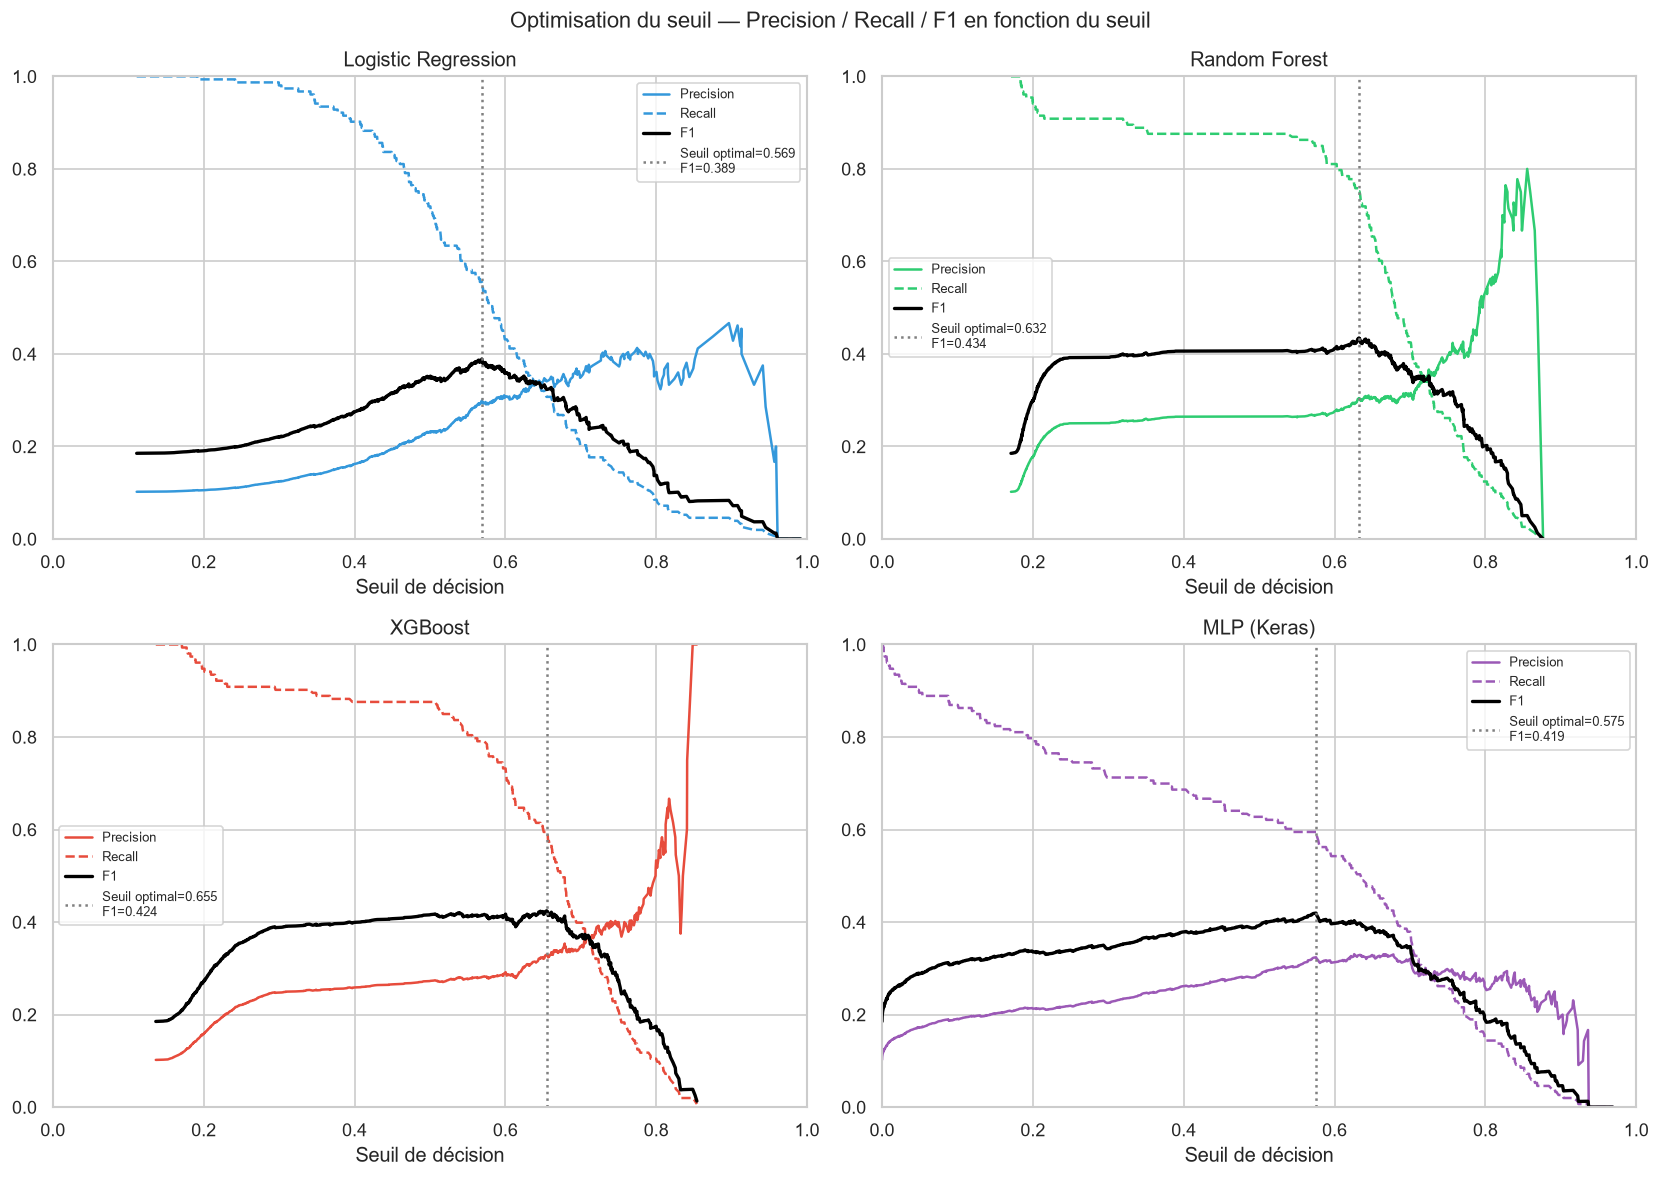

Seuils optimaux retenus :
  Logistic Regression       : 0.569
  Random Forest             : 0.632
  XGBoost                   : 0.655
  MLP (Keras)               : 0.575


In [12]:
from sklearn.metrics import precision_recall_curve

models_proba = {
    'Logistic Regression': lr_proba_val,
    'Random Forest':       rf_proba_val,
    'XGBoost':             xgb_proba_val,
    'MLP (Keras)':         mlp_proba_val,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
thresholds_opt = {}

for i, (name, proba) in enumerate(models_proba.items()):
    precs, recs, threshs = precision_recall_curve(y_val, proba)
    f1_curve = 2 * precs * recs / (precs + recs + 1e-8)
    best_idx  = np.argmax(f1_curve[:-1])
    best_t    = threshs[best_idx]
    best_f1   = f1_curve[best_idx]
    thresholds_opt[name] = best_t

    ax = axes[i]
    ax.plot(threshs, precs[:-1], label='Precision', color=colors[i], linewidth=1.5)
    ax.plot(threshs, recs[:-1],  label='Recall',    color=colors[i], linewidth=1.5, linestyle='--')
    ax.plot(threshs, f1_curve[:-1], label='F1',     color='black',   linewidth=2)
    ax.axvline(best_t, color='gray', linestyle=':', linewidth=1.5,
               label=f'Seuil optimal={best_t:.3f}\nF1={best_f1:.3f}')
    ax.set_title(name)
    ax.set_xlabel('Seuil de décision')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Optimisation du seuil — Precision / Recall / F1 en fonction du seuil', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_threshold_optimization.png', bbox_inches='tight')
plt.show()

print('Seuils optimaux retenus :')
for name, t in thresholds_opt.items():
    print(f'  {name:25s} : {t:.3f}')

## 8. Comparaison finale : val set avec seuils optimisés

In [13]:
# Appliquer le seuil optimal de chaque modèle
all_metrics = []
model_objects = {
    'Logistic Regression': (lr_best, lr_proba_val),
    'Random Forest':       (rf_best, rf_proba_val),
    'XGBoost':             (xgb_best, xgb_proba_val),
    'MLP (Keras)':         (best_mlp, mlp_proba_val),
}

for name, (model, proba) in model_objects.items():
    t    = thresholds_opt[name]
    pred = (proba >= t).astype(int)
    m    = get_metrics(y_val, pred, proba, name)
    m['seuil_optimal'] = round(t, 3)
    all_metrics.append(m)

comparison_df = pd.DataFrame(all_metrics).set_index('model').sort_values('f1', ascending=False)

print('=== Comparaison sur le VAL SET (seuils optimisés) ===')
display(
    comparison_df.style
    .highlight_max(color='#d4edda', subset=['f1', 'recall', 'precision', 'roc_auc', 'pr_auc'])
    .format('{:.4f}', subset=['f1', 'recall', 'precision', 'roc_auc', 'pr_auc'])
)

best_model_name = comparison_df.index[0]
print(f'\nMeilleur modèle (F1) : {best_model_name}')

=== Comparaison sur le VAL SET (seuils optimisés) ===


,f1,recall,precision,roc_auc,pr_auc,seuil_optimal
model,,,,,,
Random Forest,0.4345,0.7582,0.3045,0.8378,0.3574,0.632000
XGBoost,0.4242,0.5948,0.3297,0.8399,0.3536,0.655000
MLP (Keras),0.4194,0.5948,0.3238,0.7978,0.2600,0.575000
Logistic Regression,0.3890,0.5556,0.2993,0.7908,0.2832,0.569000



Meilleur modèle (F1) : Random Forest


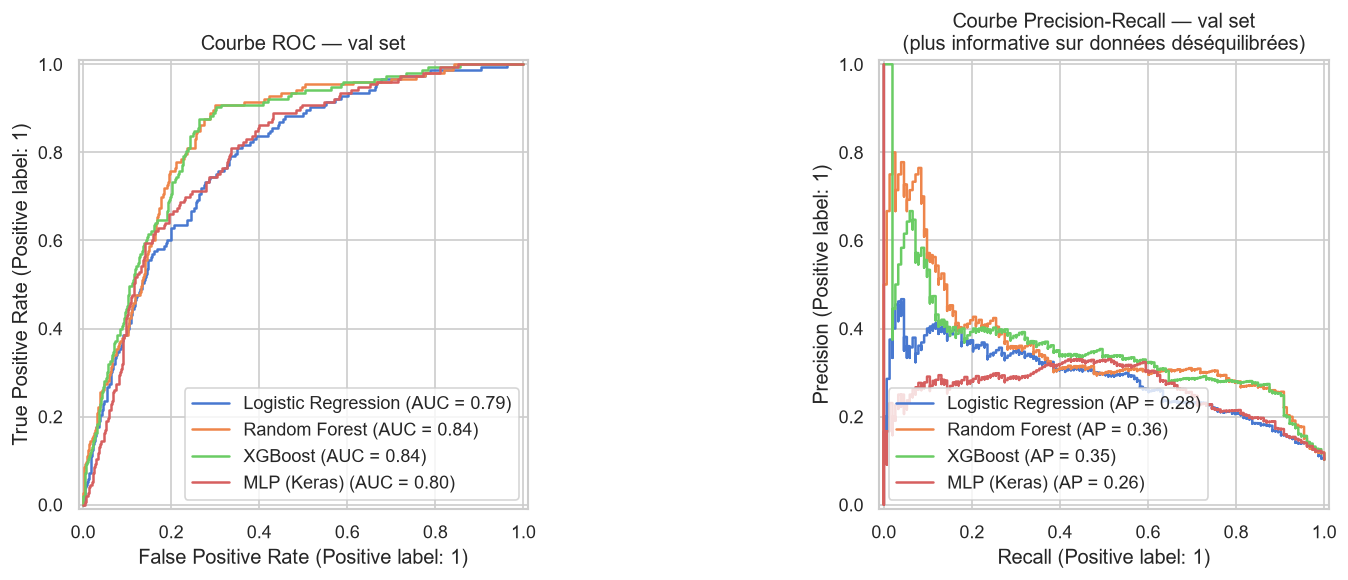

In [14]:
# Courbes ROC et Precision-Recall comparatives
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (model, proba) in model_objects.items():
    RocCurveDisplay.from_predictions(y_val, proba, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_val, proba, ax=axes[1], name=name)

axes[0].set_title('Courbe ROC — val set')
axes[1].set_title('Courbe Precision-Recall — val set\n(plus informative sur données déséquilibrées)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [15]:
import plotly.graph_objects as go

metrics_radar = ['f1', 'recall', 'precision', 'roc_auc', 'pr_auc']
fig_radar = go.Figure()
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    vals = [row[m] for m in metrics_radar]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=metrics_radar + [metrics_radar[0]],
        fill='toself', name=model_name,
        line_color=palette[i % len(palette)],
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Comparaison radar des modeles — val set',
    height=500,
)
fig_radar.show()

try:
    fig_radar.write_image(str(FIGURES_DIR / '03_radar_models.png'))
    print('Radar chart sauvegarde.')
except Exception:
    print('(kaleido non installe — radar non sauvegarde en PNG, visible dans le notebook)')

(kaleido non installe — radar non sauvegarde en PNG, visible dans le notebook)


## 9. Évaluation finale sur le TEST SET

Le test set n'a pas été utilisé jusqu'ici. On l'utilise **une seule fois** pour
reporter les métriques finales du meilleur modèle. C'est la valeur qui va dans le rapport.

=== RÉSULTATS FINAUX — TEST SET — Random Forest (seuil=0.632) ===
  F1-score  : 0.3761
  Recall    : 0.6797
  Precision : 0.2600
  ROC-AUC   : 0.7929
  PR-AUC    : 0.2733

              precision    recall  f1-score   support

 Rétentionné       0.96      0.78      0.86      1347
     Churner       0.26      0.68      0.38       153

    accuracy                           0.77      1500
   macro avg       0.61      0.73      0.62      1500
weighted avg       0.88      0.77      0.81      1500



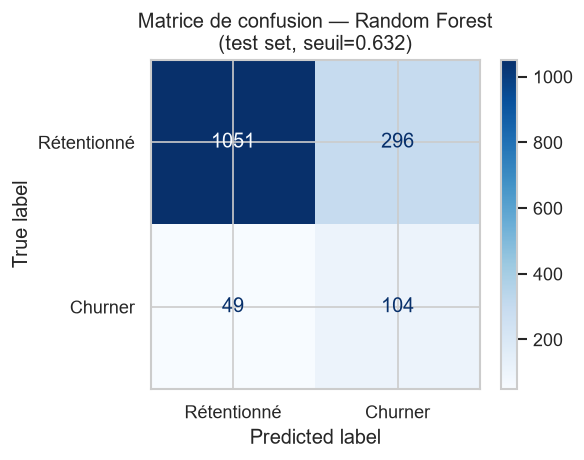

TP=104  FP=296  FN=49  TN=1051
→ 49 churners non détectés (faux négatifs = erreurs les plus coûteuses)


In [16]:
# Récupérer le meilleur modèle et son seuil
best_obj, _ = model_objects[best_model_name]
best_thresh = thresholds_opt[best_model_name]

if best_model_name == 'MLP (Keras)':
    best_proba_test = best_obj.predict(X_test_proc, verbose=0).flatten()
else:
    best_proba_test = best_obj.predict_proba(X_test_proc)[:, 1]

best_pred_test = (best_proba_test >= best_thresh).astype(int)

m_final = get_metrics(y_test, best_pred_test, best_proba_test, best_model_name)

print(f'=== RÉSULTATS FINAUX — TEST SET — {best_model_name} (seuil={best_thresh:.3f}) ===')
print(f'  F1-score  : {m_final["f1"]:.4f}')
print(f'  Recall    : {m_final["recall"]:.4f}')
print(f'  Precision : {m_final["precision"]:.4f}')
print(f'  ROC-AUC   : {m_final["roc_auc"]:.4f}')
print(f'  PR-AUC    : {m_final["pr_auc"]:.4f}')
print()
print(classification_report(y_test, best_pred_test, target_names=['Rétentionné', 'Churner']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred_test,
    display_labels=['Rétentionné', 'Churner'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matrice de confusion — {best_model_name}\n(test set, seuil={best_thresh:.3f})')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, best_pred_test).ravel()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'→ {fn} churners non détectés (faux négatifs = erreurs les plus coûteuses)')

## 10. Quantification financière

Les prédictions ne valent rien sans traduction en impact métier.

**Hypothèses :**
- Revenu moyen perdu par churner non détecté (FN) : **238 €** (médiane `total_revenue` des churners)
- Coût d'une action de rétention ciblée (FP ou TP) : **30 €** (email personnalisé + offre)
- Taux de succès d'une campagne de rétention : **25%** (1 churner sur 4 change d'avis)

**Calcul du ROI de la solution :**

In [17]:
COST_FN        = 238   # revenu moyen d'un churner non detecte
COST_FP        = 30    # cout d'une campagne de retention inutile
RETENTION_RATE = 0.25  # % de vrais churners sauves par la campagne
N_TOTAL        = len(arts['y_train']) + len(arts['y_val']) + len(arts['y_test'])

tn, fp, fn, tp = confusion_matrix(y_test, best_pred_test).ravel()

n_real_churners = tp + fn
cost_no_model   = n_real_churners * COST_FN

cost_fn_missed   = fn * COST_FN
cost_campaign    = (tp + fp) * COST_FP
gain_retention   = tp * RETENTION_RATE * COST_FN
net_cost_model   = cost_fn_missed + cost_campaign - gain_retention

saving = cost_no_model - net_cost_model

print('=== ANALYSE COUT-BENEFICE (test set) ===')
print(f'\n  Churners reels dans le test set    : {n_real_churners}')
print(f'  Churners detectes (TP)             : {tp}')
print(f'  Churners manques (FN)              : {fn}')
print(f'  Faux positifs (FP)                 : {fp}')
print()
print('  SANS MODELE')
print(f'    Cout total (tous les churners perdus) : {cost_no_model:,.0f} EUR')
print()
print('  AVEC MODELE')
print(f'    Cout des FN (churners manques)        : {cost_fn_missed:,.0f} EUR')
print(f'    Cout des actions de retention          : {cost_campaign:,.0f} EUR')
print(f'    Gain (churners sauves x 25%)           : -{gain_retention:,.0f} EUR')
print(f'    Cout net avec modele                   : {net_cost_model:,.0f} EUR')
print()
print(f'  ECONOMIE NETTE = {saving:,.0f} EUR  ({saving/cost_no_model:.1%} du cout initial)')
print()
factor = N_TOTAL / len(y_test)
print(f'  Extrapolation portefeuille complet ({N_TOTAL:,} clients) :')
print(f'    Economie estimee : {saving * factor:,.0f} EUR')

=== ANALYSE COUT-BENEFICE (test set) ===

  Churners reels dans le test set    : 153
  Churners detectes (TP)             : 104
  Churners manques (FN)              : 49
  Faux positifs (FP)                 : 296

  SANS MODELE
    Cout total (tous les churners perdus) : 36,414 EUR

  AVEC MODELE
    Cout des FN (churners manques)        : 11,662 EUR
    Cout des actions de retention          : 12,000 EUR
    Gain (churners sauves x 25%)           : -6,188 EUR
    Cout net avec modele                   : 17,474 EUR

  ECONOMIE NETTE = 18,940 EUR  (52.0% du cout initial)

  Extrapolation portefeuille complet (10,000 clients) :
    Economie estimee : 126,267 EUR


## 11. Sauvegarde du modèle final

In [18]:
# Sauvegarder le modèle final
if best_model_name == 'MLP (Keras)':
    best_obj.save(MODELS_DIR / 'best_model_churn.keras')
    print(f'✓ Modèle MLP sauvegardé → best_model_churn.keras')
else:
    joblib.dump(best_obj, MODELS_DIR / 'best_model_churn.joblib')
    print(f'✓ Modèle {best_model_name} sauvegardé → best_model_churn.joblib')

# Sauvegarder le tableau de comparaison pour le dashboard
joblib.dump(comparison_df, MODELS_DIR / 'churn_comparison.joblib')

# Sauvegarder les métadonnées pour le notebook 04 (SHAP)
modeling_artifacts = {
    'best_model_name':   best_model_name,
    'best_threshold':    best_thresh,
    'best_proba_test':   best_proba_test,
    'best_pred_test':    best_pred_test,
    'comparison_df':     comparison_df,
    'thresholds_opt':    thresholds_opt,
    'scale_pos_weight':  scale_pw,
    'metrics_final':     m_final,
}
joblib.dump(modeling_artifacts, MODELS_DIR / 'modeling_artifacts.joblib')

print(f'Artefacts de modélisation sauvegardés → modeling_artifacts.joblib')
print(f'\n=== BILAN FINAL ===')
print(f'Modèle retenu   : {best_model_name}')
print(f'Seuil optimal   : {best_thresh:.3f}')
print(f'F1-score (test) : {m_final["f1"]:.4f}')
print(f'PR-AUC (test)   : {m_final["pr_auc"]:.4f}')
print(f'Recall (test)   : {m_final["recall"]:.4f}')

✓ Modèle Random Forest sauvegardé → best_model_churn.joblib
Artefacts de modélisation sauvegardés → modeling_artifacts.joblib

=== BILAN FINAL ===
Modèle retenu   : Random Forest
Seuil optimal   : 0.632
F1-score (test) : 0.3761
PR-AUC (test)   : 0.2733
Recall (test)   : 0.6797
